In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, average_precision_score, PrecisionRecallDisplay
import shap

# 1. Daten laden
# Wir schauen uns nur die Namen an, wie gewünscht.
df = pd.read_csv('../../data/full_merge_df.csv')

C:\Users\blemi\AppData\Local\Temp\ipykernel_34096\3223523530.py:10: DtypeWarning: Columns (46,48,52,65,68,70,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,189,200,241,244,246,252,260,262,266,272,274,276,278,280,282,284,286,288,290,292,294,423,425,456,469,478,629,698,714,731,734,751,859,993,994,995,996,1006,1031,1034) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../data/full_merge_df.csv')


In [3]:
# 2. Variablen-Definition (exakt nach Vorgabe)
features = [ #For prevention
    # 1. Basis-Kontrollvariablen (Nicht veränderbar, aber zwingend als Baseline)
    'NACCAGE', 'SEX', 'EDUC',                    # Demografie & Kognitive Reserve (Bildung schützt!)
    'NACCNE4S',                                  # APOE4-Status (Wir behalten nur den stärksten genetischen Marker zur Risikostratifizierung)
    # 2. Kardiovaskuläre & Stoffwechsel-Gesundheit (Der wichtigste Hebel!)
    'HYPERTEN',                                  # Bluthochdruck (Sehr gut medikamentös einstellbar)
    'DIABETES',                                  # Diabetes (Ernährung / Insulin)
    'NACCBMI',                                   # Body-Mass-Index (Lebensstil / Gewicht)
    'HYPERCHO',                                  # Hypercholesterinämie (Hohes Cholesterin, gut behandelbar)
    'CVHATT',                                    # Historie von Herzinfarkten (Vaskuläre Risiken) 
    # 3. Lebensstil & Schlaf (Direkt durch Verhalten veränderbar)
    'TOBAC100',                                  # Raucherstatus (Rauchstopp als Prävention)
    'SLEEPAP',                                   # Schlafapnoe (Extrem wichtig! Führt zu Sauerstoffmangel im Gehirn, behandelbar mit CPAP-Maske)
    'ALCOHOL',                                   # Alkoholmissbrauch 
    # 4. Psychische & Emotionale Gesundheit (Oft Vorboten oder Treiber)
    'DEP2YRS',                                   # Depression in den letzten 2 Jahren (Therapie/Antidepressiva)
    'APA',                                       # Apathie (Früher Marker für Abbau, aktivierbar durch soziale Programme)
    'ANXIETY',                                   # Angststörungen
    # 5. Behandelbare physische Mangelzustände
    'B12DEF',                                    # Vitamin B12 Mangel (Einfach zu beheben durch Supplemente)
    'THYROID',                                   # Schilddrüsenerkrankungen (Können Demenz-Symptome imitieren)
    # 6. Kognitiver Startpunkt (Um zu wissen, wo der Patient beginnt)
    'NACCMMSE'                                   # Globaler Score reicht hier als Baseline völlig aus
]

# 3. Target-Erstellung (Beispielhafte Logik für MCI_TO_NL vs MCI_TO_MCI)
# Hinweis: Hier müsste Ihre spezifische Spalte für den Statuswechsel genutzt werden.
# Wir nehmen an, die Spalte 'TARGET' existiert bereits oder wird hier gefiltert.
# 1. Zuerst filtern und sortieren (nach ID und Zeit)
df_model = df[df['Group'].isin(['MCI to NL', 'MCI to MCI'])].sort_values(['NACCID', 'NACCVNUM'])

# 2. Dann die Duplikate entfernen, um nur die Baseline zu behalten
df_model = df_model.drop_duplicates(subset=['NACCID'], keep='first').copy()

# 3. ERST JETZT die Zielvariable 'target' im bereinigten DataFrame erstellen
df_model['target'] = (df_model['Group'] == 'MCI to NL').astype(int)

# 4. Jetzt sind X und y korrekt definiert
X = df_model[features]
y = df_model['target']

# 4. Split in Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Berechnung des scale_pos_weight für Class Imbalance
# Formel: sum(negative instances) / sum(positive instances)
ratio = float(np.sum(y == 0)) / np.sum(y == 1)
print(f"Berechnetes scale_pos_weight: {ratio:.2f}")


Berechnetes scale_pos_weight: 1.61


In [4]:
# Initialisierung des Modells
# Wir nutzen die GPU, falls vorhanden, sonst CPU.
model = xgb.XGBClassifier(
    n_estimators=1500,
    max_depth=4,                # Moderate Tiefe zur Vermeidung von Overfitting bei kleinen N
    learning_rate=0.05,
    subsample=0.8,
    early_stopping_rounds=50,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,      # Ausgleich der Klassenimbalance
    use_label_encoder=False,
    monotone_constraints=(-1,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1),
    eval_metric='aucpr',           # Optimierung auf AUC, da wir Reverter finden wollen
    random_state=42
)

# Training mit Early Stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f"Bester Iterationsschritt: {model.best_iteration}")


C:\Users\blemi\AppData\Roaming\Python\Python314\site-packages\xgboost\callback.py:385: UserWarning: [13:20:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


Bester Iterationsschritt: 82


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.67      0.75         9
           1       0.62      0.83      0.71         6

    accuracy                           0.73        15
   macro avg       0.74      0.75      0.73        15
weighted avg       0.76      0.73      0.74        15

PR-AUC (Average Precision): 0.8357
--- Confusion Matrix ---
[[6 3]
 [1 5]]


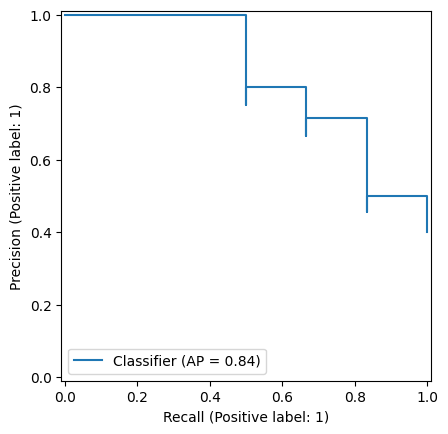

In [5]:
# Vorhersagen
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

# Metriken
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Berechnung der Average Precision
pr_auc = average_precision_score(y_test, y_probs)
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

# Visualisierung der Kurve
PrecisionRecallDisplay.from_predictions(y_test, y_probs)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("--- Confusion Matrix ---")
print(cm)


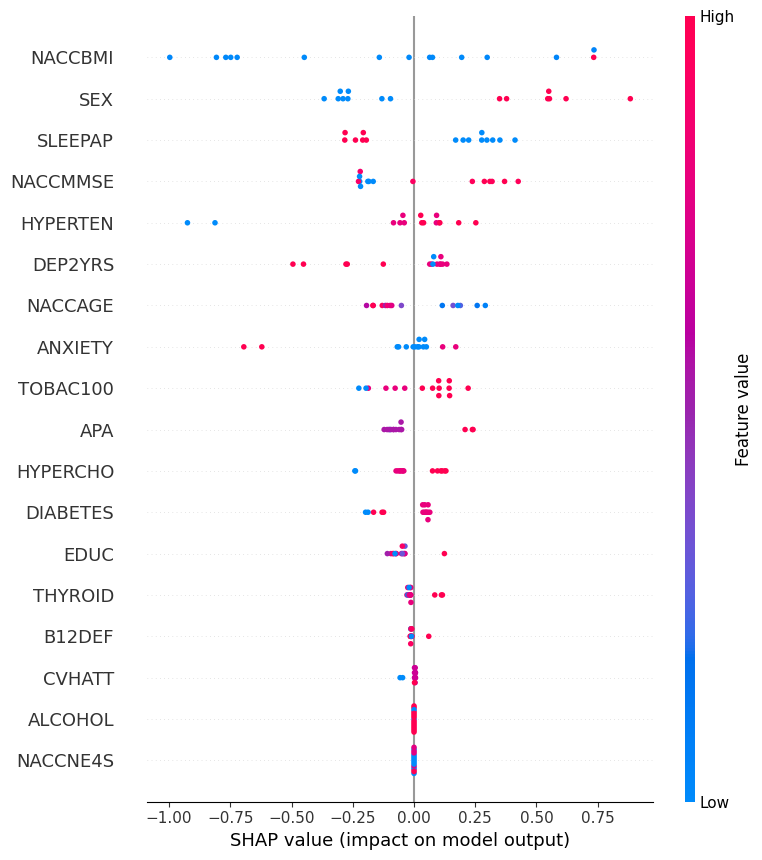

18 are being loaded.
Loading feature: NACCAGE.


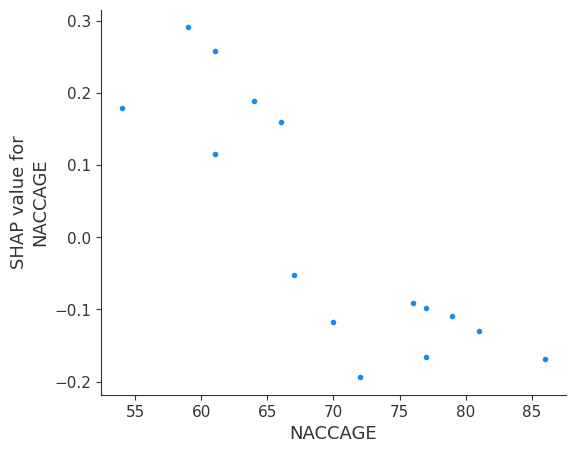

NACCAGE plotted succesfully.
Loading feature: SEX.


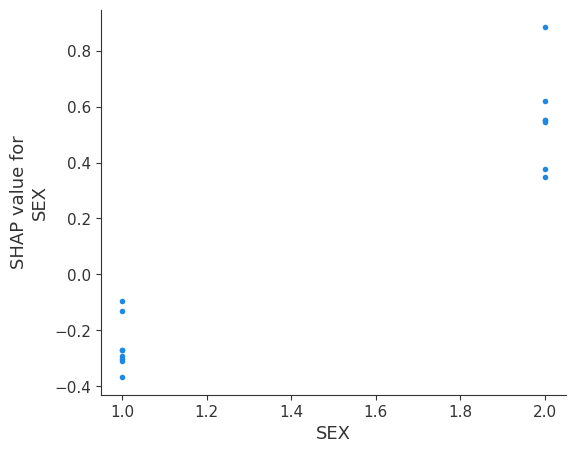

SEX plotted succesfully.
Loading feature: EDUC.


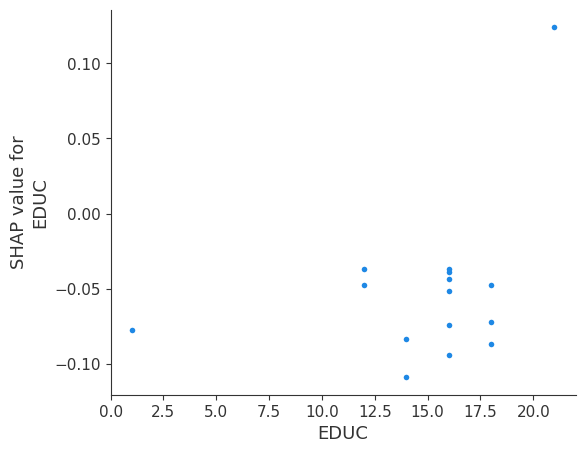

EDUC plotted succesfully.
Loading feature: NACCNE4S.


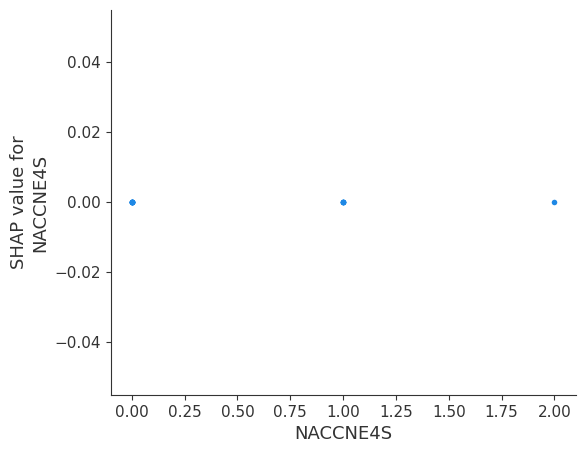

NACCNE4S plotted succesfully.
Loading feature: HYPERTEN.


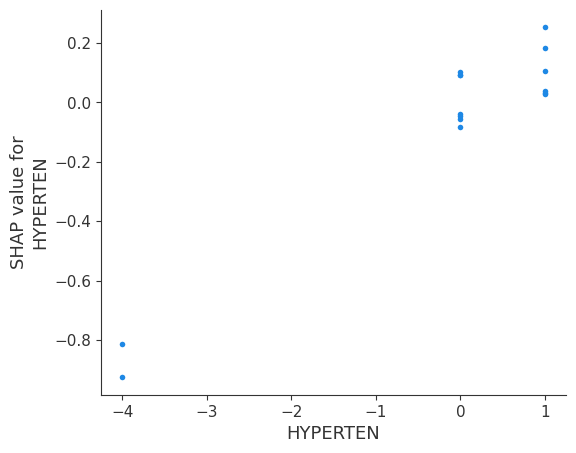

HYPERTEN plotted succesfully.
Loading feature: DIABETES.


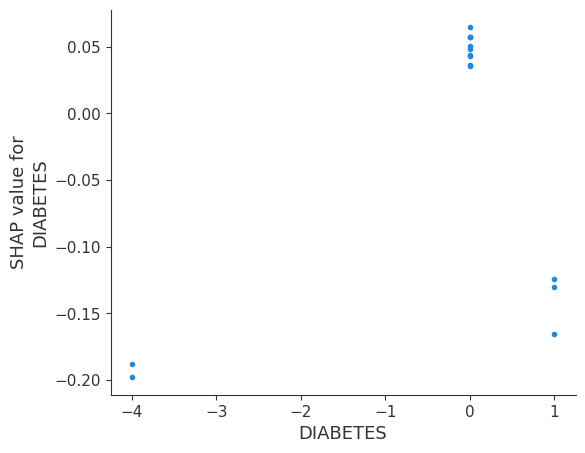

DIABETES plotted succesfully.
Loading feature: NACCBMI.


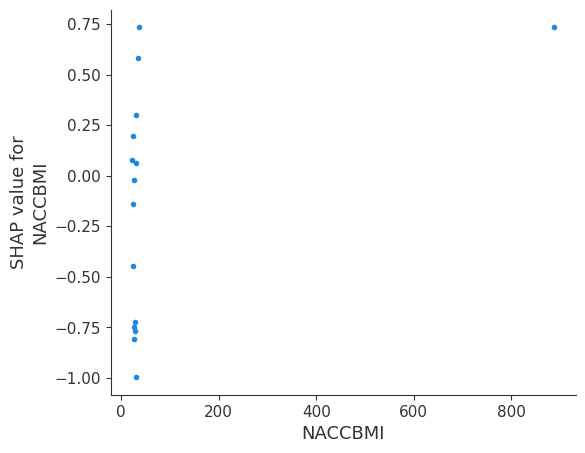

NACCBMI plotted succesfully.
Loading feature: HYPERCHO.


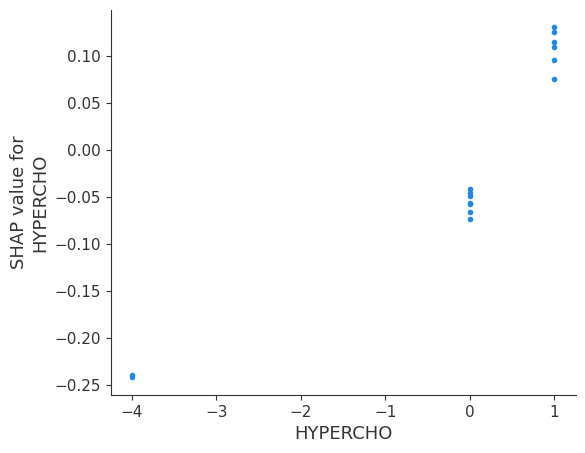

HYPERCHO plotted succesfully.
Loading feature: CVHATT.


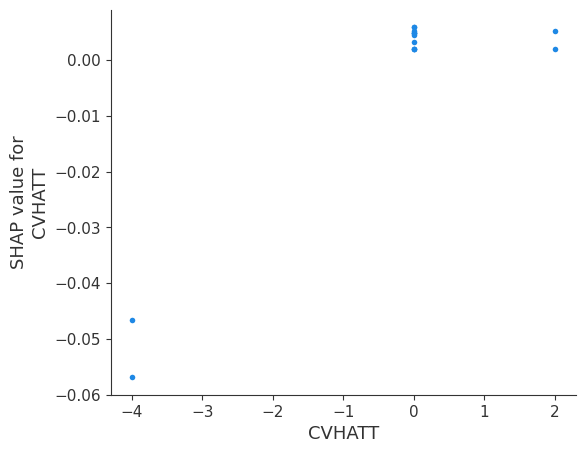

CVHATT plotted succesfully.
Loading feature: TOBAC100.


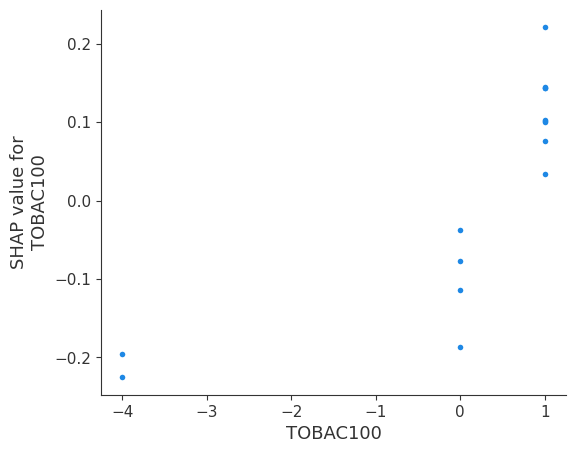

TOBAC100 plotted succesfully.
Loading feature: SLEEPAP.


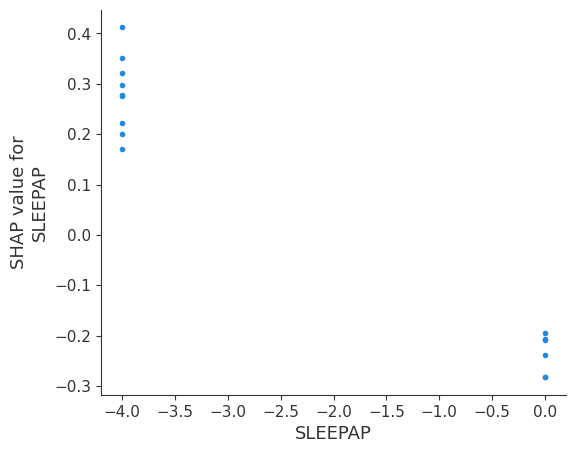

SLEEPAP plotted succesfully.
Loading feature: ALCOHOL.


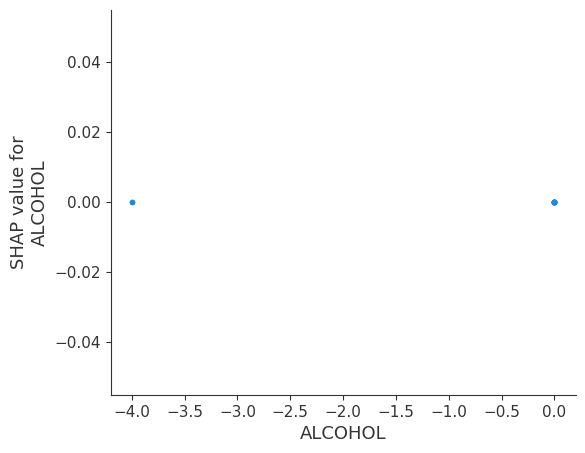

ALCOHOL plotted succesfully.
Loading feature: DEP2YRS.


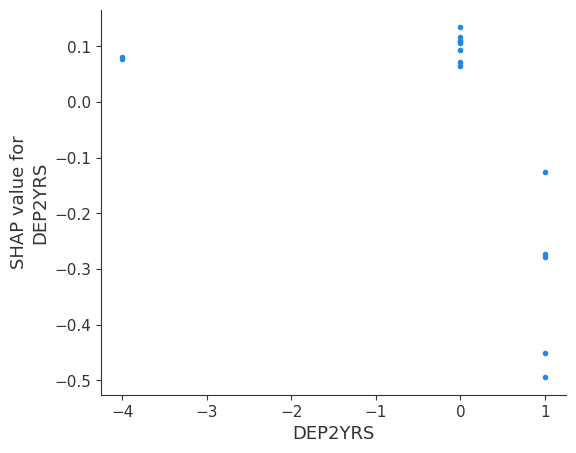

DEP2YRS plotted succesfully.
Loading feature: APA.


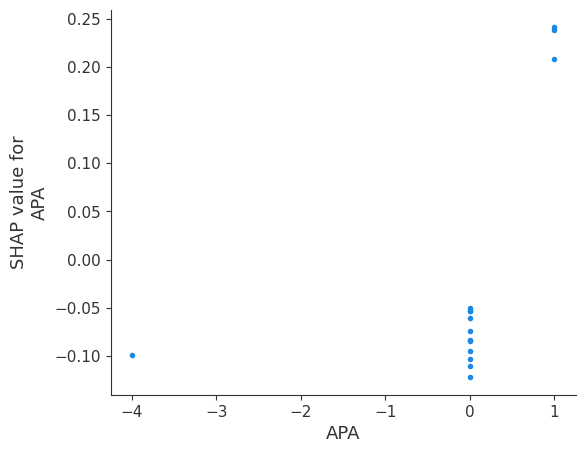

APA plotted succesfully.
Loading feature: ANXIETY.


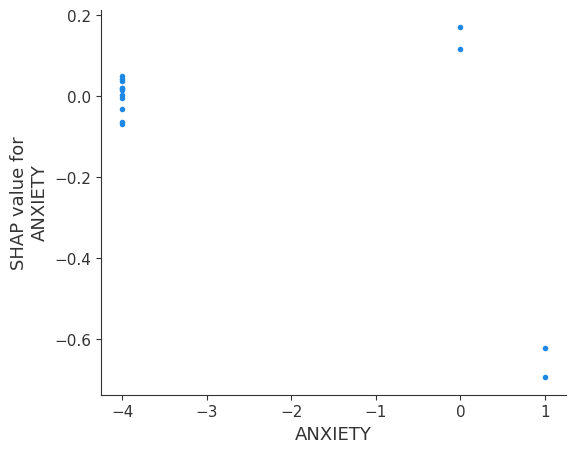

ANXIETY plotted succesfully.
Loading feature: B12DEF.


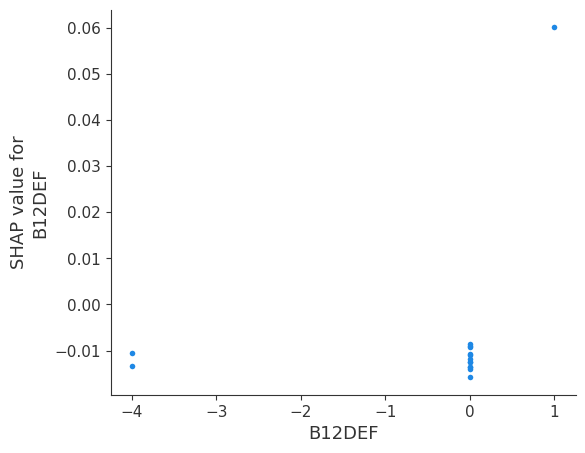

B12DEF plotted succesfully.
Loading feature: THYROID.


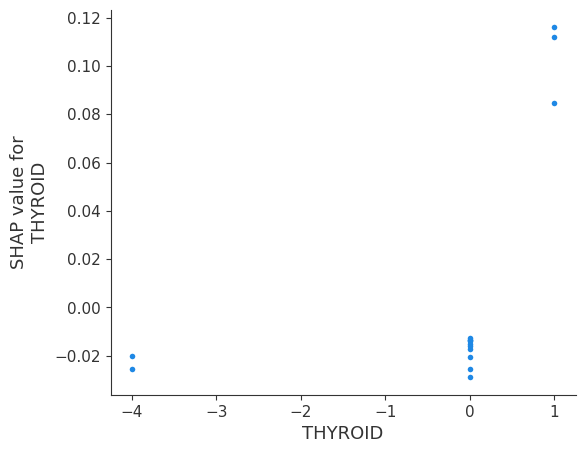

THYROID plotted succesfully.
Loading feature: NACCMMSE.


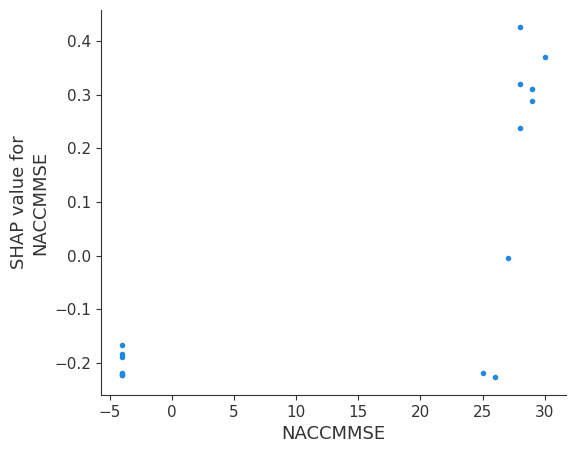

NACCMMSE plotted succesfully.


In [ ]:
# SHAP Explainer initialisieren
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary Plot
# Zeigt die Feature-Bedeutung und die Richtung des Effekts
shap.summary_plot(shap_values, X_test, plot_type="dot")

# Kommentar: In diesem Plot können wir sehen, ob z.B. hohe CSFABETA-Werte (Amyloid) 
# eher mit einer Stabilisierung (MCI to MCI) oder einer Heilung (MCI to NL) korrelieren.

# Zeigt den exakten Einfluss pro BMI-Punkt oder Altersjah
print(f"{len(features)} feature plots are being loaded.")
for feature in features:
  print(f"Loading feature: {feature}.")
  shap.dependence_plot(feature, shap_values, X_test, interaction_index=None)
  print(f"{feature} plotted succesfully.")
